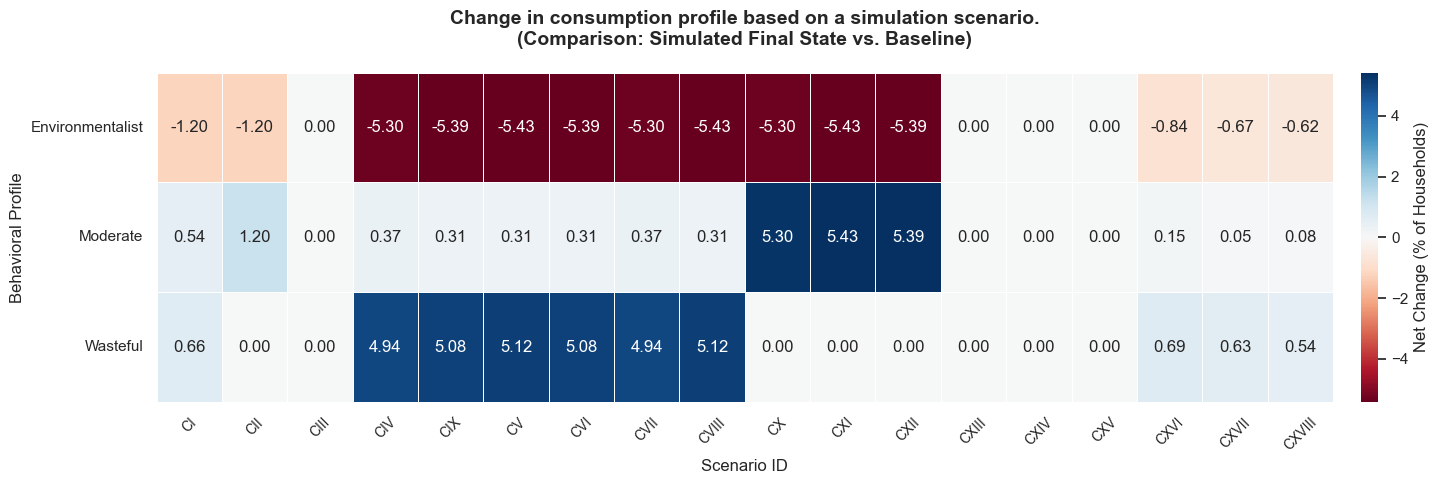

Success! Horizontal map saved: ../resultados/figure-net-behavioral-shift-heatmap-h-fig13.pdf


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

# Standardized Paths
INPUT_FILE = '../resultados/comparativo_perfil_cenarios_qgis.csv'
OUTPUT_PDF = '../resultados/figure-net-behavioral-shift-heatmap-h-fig13.pdf'
OUTPUT_PNG = '../resultados/figure-net-behavioral-shift-heatmap-h-fig13.png'

def natural_sort_key(s):
    """Sort scenarios (CI, CII, CIII... CXVIII) in natural order."""
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split(r'(\d+)', s)]

def generate_behavioral_impact_map_horizontal():
    if not os.path.exists(INPUT_FILE):
        print(f"Error: {INPUT_FILE} not found.")
        return

    # 1. Load data (Using ';' as defined in the previous GAMA adjustment)
    df = pd.read_csv(INPUT_FILE, sep=',')
    
    # 2. Extract Baseline and Totals
    unique_scenarios = sorted(df['NM_CENARIO'].unique(), key=natural_sort_key)
    total_agents = len(df[df['NM_CENARIO'] == unique_scenarios[0]])
    initial_dist = df[df['NM_CENARIO'] == unique_scenarios[0]]['TP_COMPORTAMENTO'].value_counts()
    
    # 3. Process each scenario
    profiles = ['AMBIENTALISTA', 'MODERADO', 'PERDULARIO']
    impact_data = []

    for scenario in unique_scenarios:
        df_scen = df[df['NM_CENARIO'] == scenario]
        final_dist = df_scen['TP_NOVO_COMPORTAMENTO'].value_counts()
        
        row = {'Scenario': scenario}
        for p in profiles:
            net_change = ((final_dist.get(p, 0) - initial_dist.get(p, 0)) / total_agents) * 100
            row[p] = net_change
        impact_data.append(row)

    # 4. Transpose for Horizontal Layout
    # Original: Index=Scenarios, Columns=Profiles
    # Transposed: Index=Profiles, Columns=Scenarios
    impact_df = pd.DataFrame(impact_data).set_index('Scenario').T

    # 5. Plotting (Wide format for better horizontal viewing)
    plt.figure(figsize=(16, 5)) 
    sns.set_theme(style="white")
    
    ax = sns.heatmap(
        impact_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdBu", 
        center=0,
        linewidths=.5,
        cbar_kws={'label': 'Net Change (% of Households)', 'pad': 0.02}
    )
    
    plt.title("Change in consumption profile based on a simulation scenario.\n(Comparison: Simulated Final State vs. Baseline)", 
              fontsize=14, fontweight='bold', pad=20)
    plt.ylabel("Behavioral Profile", fontsize=12)
    plt.xlabel("Scenario ID", fontsize=12)
    
    # Standardizing profile labels
    ax.set_yticklabels(['Environmentalist', 'Moderate', 'Wasteful'], rotation=0, fontsize=11)
    ax.set_xticklabels(unique_scenarios, rotation=45, fontsize=10)
    
    plt.tight_layout()
    
    # 6. Saving
    plt.savefig(OUTPUT_PDF, format='pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_PNG, format='png', dpi=300, bbox_inches='tight')
    
    # Display the result
    plt.show()
    
    print(f"Success! Horizontal map saved: {OUTPUT_PDF}")

if __name__ == "__main__":
    generate_behavioral_impact_map_horizontal()